---
title: "Linear Regression From Scratch"
author: "Miguel R."
date: today
categories: [supervised learning, linear regression]
description: "This is a linear regression from scratch."
---

I wanted to do the most simplest linear regression algorithm possible.
# What is Linear Regression
- Linear Regression is a supervised learning algorithm that attempts to model the relationship between a scalar dependent variable y and one or more independent variables X.

In simple terms, we are trying to find a line that passes through the data points,
 in such a way that minimizes the distance between the line and the points.

In this case we are going to use a straight line to fit the data.

So the structure of a straight line is defined by two parameters:
- the slope ($m$)
- the intercept ($b$).

The equation of a straight line is given by
$$y = mx + b$$
where $m$ is the slope and $b$ is the y-intercept.


In [1]:
import numpy as np


# initial parameters of the slope and the intercept

def predict(X, m, b):
    return (m * X) + b


m = 3
b = 60
X = np.array([2, 3, 5, 6, 8])
y_true = np.array([65, 70, 75, 85, 90])

# The Data
We are just creating 5 data points for demonstration purposes.
Let's say we have data for hours worked $x$ and money earned $y$.

| Point | $x$ | $y$ |
|-------|-----|-----|
| a     | 2   | 65  |
| b     | 3   | 70  |
| c     | 5   | 75  |
| d     | 6   | 85  |
| e     | 8   | 90  |

and we are drawing a close line, but not fitted yet,
just to give more theory about the linear regression.

our line $y = mx + b$ is
$$y = 3x + 60$$
where the intersection with the y-axis is at $60$ and the slope is $3$.


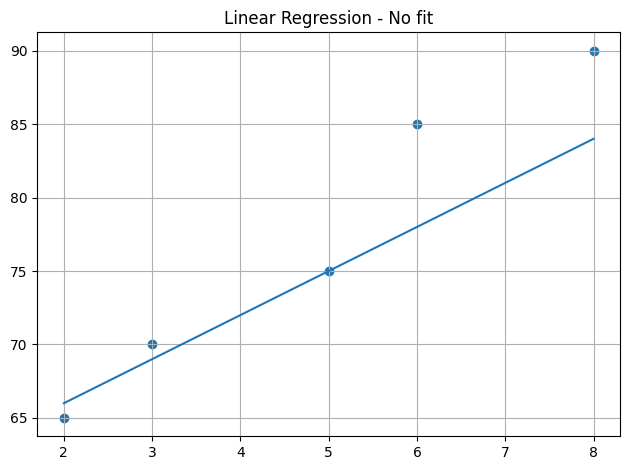

In [2]:
no_fit_prediction = predict(X, m, b)
from plot_utils import plot_fit

plot_fit(X, y_true, no_fit_prediction, "Linear Regression - No fit")

oue initial line (prediction) we could say that it is not a good fit for the data,
but here we are going to search for the best fit line using gradient descent.

In [3]:
import numpy as np


def loss_mse(y_true, predicted):
    return np.mean((y_true - predicted) ** 2)


initial_loss = loss_mse(y_true, no_fit_prediction)
print(f"Initial Loss: {initial_loss:.2f}")


Initial Loss: 17.40


# Loss Function
We need to establish our loss metric.
In this case, we are going to use the mean squared error (MSE) as our loss function.

The MSE formula is given by:
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

where:
- $n$ is the number of observations,
- $y_i$ is the true value,
- $\hat{y}_i$ is the predicted value.

## Manually calculating it

| Point | $x$ | $y$  | calc              | $\hat{y}$ | $y-\hat{y}$ | $(y-\hat{y})^2$ |
|-------|-----|------|-------------------|-----------|-------------|-----------------|
| a     | $2$ | $65$ | $(3\times2) + 60$ | $66$      | $-1$        | $1$             |
| b     | $3$ | $70$ | $(3\times3) + 60$ | $69$      | $ 1$        | $1$             |
| c     | $5$ | $75$ | $(3\times5) + 60$ | $75$      | $ 0$        | $0$             |
| d     | $6$ | $85$ | $(3\times6) + 60$ | $78$      | $ 7$        | $49$            |
| e     | $8$ | $90$ | $(3\times8) + 60$ | $84$      | $ 6$        | $36$            |

then,
$$MSE = \frac{1 + 1 + 0 + 49 + 36}{ 5} = 17.40$$



In [4]:
from plot_utils import plot_slope


def update(X, y_true, y_pred, m, b, learning_rate, plot=False):
    y_true_pred = y_true - y_pred
    X_y_true_pred = X * y_true_pred
    dm = -2 * np.mean(X_y_true_pred)
    db = -2 * np.mean(y_true_pred)
    new_m = m - learning_rate * dm
    new_b = b - learning_rate * db
    if plot:
        print(f"new_m{new_m} - new_b{new_b} -> dm{dm} - db{db}")
        plot_slope(new_m, new_b)
    return new_m, new_b


## The update function
This is how we find a better value for $m$ and $b$.

in simple terms, we identify the direction where we can improve,
then we move to that direction at the rate of the `learning_rate`.
as an example, we are going to manually calculate the first three iterations,
and our starting point is $m = 0$ and $b = 0$

### First Epoch
The first epoch prediction is all $0$.

| Point | $x$ | $\hat{y}$ | $y$ |
|-------|-----|-----------|-----|
| a     | 2   | 0         | 65  |
| b     | 3   | 0         | 70  |
| c     | 5   | 0         | 75  |
| d     | 6   | 0         | 85  |
| e     | 8   | 0         | 90  |


$X \times y_i - \hat{y}_i = [2,3,5,6,8] \times [65,70,75,85,90] = [130,210,375,510,720]$

$np.mean(X \times (y_i - \hat{y}_i)) = \frac{130+210+375+510+720}{5} = 389$

$np.mean(y_i - \hat{y}_i) = \frac{65,70,75,85,90}{5} = 77$

$dm = -2 \times 389 = -778$

$db = -2 \times 77 = -154$

$m_{new} = m - \text{learning rate} * dm = 0 - 0.01\times(-778) = 7.78$
$b_{new} = b - \text{learning rate} * db = 0 - 0.01\times(-154) = 1.54$

### Second Epoch
We use the updated $m = 7.78$ and $b = 1.54$

$$\text{point } a \text{, our } \hat{y} = 7.78\times2 + 1.54 = 17.1$$

$$\text{point } b \text{, our } \hat{y} = 7.78\times3 + 1.54 = 24.88$$
$$\text{point } c \text{, our } \hat{y} = 7.78\times5 + 1.54 = 40.44$$
$$\text{point } d \text{, our } \hat{y} = 7.78\times6 + 1.54 = 48.22$$
$$\text{point } e \text{, our } \hat{y} = 7.78\times8 + 1.54 = 63.78$$

| Point | $x$ | $\hat{y}$ | $y$ | $y-\hat{y}$ |
|-------|-----|-----------|-----|-------------|
| a     | 2   | 17.1      | 65  | 47.9        |
| b     | 3   | 24.88     | 70  | 45.12       |
| c     | 5   | 40.44     | 75  | 34.56       |
| d     | 6   | 48.22     | 85  | 36.78       |
| e     | 8   | 63.78     | 90  | 26.22       |


$X \times y_i - \hat{y}_i = [2,3,5,6,8] \times [47.9,45.12,34.56,36.78,26.22] = [95.8,135.36,172.8,220.68, 209.76]$

$np.mean(X \times (y_i - \hat{y}_i)) = \frac{95.8+135.36+172.8+220.68+ 209.76 }{5} = 166.88$

$np.mean(y_i - \hat{y}_i) = \frac{47.9+45.12+34.56+36.78+26.22}{5} = 38.116$

$dm = -2 \times 166.88 = -333.76$

$db = -2 \times 77 = -76.23$

$m_{new} = m - \text{learning rate} * dm = 7.78 - 0.01\times(-333.76) = 11.11$

$b_{new} = b - \text{learning rate} * db = 1.54 - 0.01\times(-76.23) = 2.30$




Epoch: 0, Loss: 6015.0000
new_m7.78 - new_b1.54 -> dm-778.0 - db-154.0


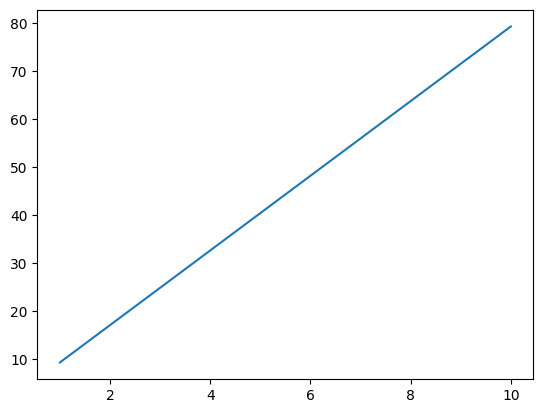

new_m11.117600000000001 - new_b2.30232 -> dm-333.76000000000005 - db-76.232


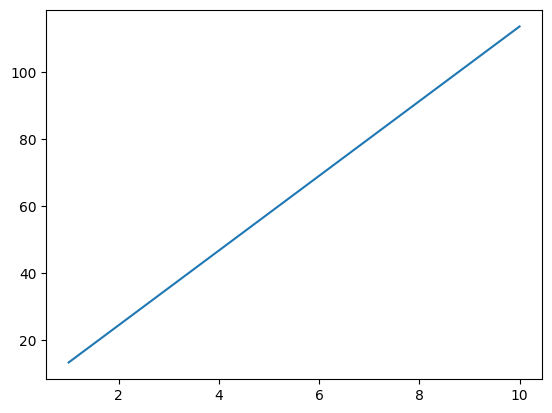

Error removing breakpoint: Breakpoint id not found: c505bb0983006aab6b8d96e2b56ed3cdd0b5ef1b5361a404572668b8edc53c56 id: 14. Available ids: []



In [ ]:
m = 0.0
b = 0.0
epochs = 3000
learning_rate = 0.01
loss_history = []
slope_history = []

for epoch in range(epochs):
    y_pred = predict(X, m, b)
    current_loss = loss_mse(y_true, y_pred)
    loss_history.append(current_loss)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, Loss: {current_loss:.4f}")
    m, b = update(X, y_true, y_pred, m, b, learning_rate, plot=epoch < 3)
    slope_history.append((m, b))

    if epoch == epochs - 1:
        final_loss = current_loss
        print(f"Final Loss: {final_loss:.4f}")
        print(f"Final Slope: {m:.4f}, Final Intercept: {b:.4f}")

from plot_utils import plot_loss, create_interactive_line_chart, create_interactive_plot

create_interactive_line_chart(dataset=slope_history, x_range=(60, 100))
plot_loss(loss_history)



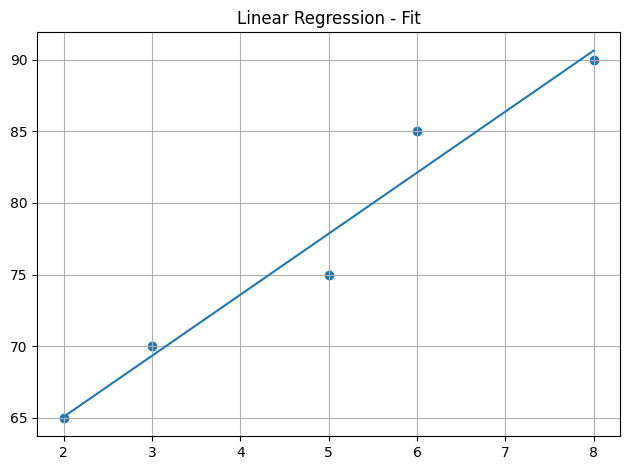

Fit Loss: 3.46


In [6]:
fit_predicted = predict(X, m, b)
plot_fit(X, y_true, fit_predicted, "Linear Regression - Fit")

fit_loss = loss_mse(y_true, fit_predicted)
print(f"Fit Loss: {fit_loss:.2f}")


# Takeaways
- inicialmente tratamos de adivinar el valor de m y b, para darle mas marco teorico al modelo.
- la parte que es mas matematicamente profunda es sacar la derivada de la funcion de perdida con respecto a m y b.
- hicimos un hardcode de  cuando debe parar la funcion de perdida, esto es manejado diferente dependiendo de las librerias que usemos en linear regression.
